In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
torch.set_default_dtype(torch.float64)
from kan import *
from kan.utils import create_dataset
from torch.autograd import grad
from argparse import Namespace
from functools import reduce

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()
import sys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MLP(nn.Module):
    def __init__(self, width, depth, dim):
        super(MLP, self).__init__()
        self.width = width
        if depth < 2:
          raise ValueError(f"depth must be at least 2, got {depth}")
        self.depth = depth
        self.act = nn.Tanh()

        # layer definitions
        self.FC_dict = nn.ModuleDict()
        self.FC_dict[f"layer 1"] = nn.Linear(dim, self.width)
        for i in range(2, depth):
          self.FC_dict[f"layer {i}"] = nn.Linear(self.width, self.width)
        self.FC_dict[f"layer {depth}"] = nn.Linear(self.width, 1)

    def forward(self, x):
      for key, layer in self.FC_dict.items():
        x = layer(x)
        if key != f"layer {self.depth}":
          x = self.act(x)
      return x

def run():
    batchsize = 101 
    batchsize_b = 101 
    weight = 0.005  
    update_grid_freq = 5
    stop_update_grid_step = 100
    step = 100
    dimen = 2
    loss_choice = "DRM"
    # Grab the arguments that are passed in
   
    
    model_type = 'KAN3'#['KAN3','KAN','MLP']
    scales = 4 #[1,2,4,8,16,32]
    begin = 0#[-1,0]
    xx, yy,zz = np.meshgrid(model_type, scales,begin)
    params_ = np.transpose(np.array([xx.reshape(-1,), yy.reshape(-1,), zz.reshape(-1,)]))
    
    indices = np.arange(params_.shape[0])
    
    my_indices = indices#[my_task_id:indices.shape[0]:num_tasks]

    for i in my_indices:
        model_choice = params_[i][0]
        grids = [10,20,30,40]
        FREQUENCY = params_[i][1].astype('int')
        if FREQUENCY >10:
            for i in range(len(grids)):
                grids[i] =2*grids[i]        

        
# initialize a model; training points are grid-based
        torch.manual_seed(0)
        np.random.seed(0)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if model_choice == "MLP":
            WIDTH = 100
            DEPTH = 5
            model = MLP(width=WIDTH, depth=DEPTH, dim=dimen).to(device)
        else:
            WIDTH = 10
            DEPTH = 2
            if model_choice == "KAN3":
                DEPTH = 3
            kan_size = [dimen] + [WIDTH]*(DEPTH-1) + [1]
            model = KAN(width=kan_size, grid=grids[0], k=3,noise_scale=0.1, symbolic_enabled=False).to(device)
        begin_point = params_[i][2].astype('int')
        end_point  = 1
        true_losses_l2 = []
        true_losses_h1 = []

        w1 = torch.linspace(begin_point, end_point, steps=batchsize).to(device)
        w2 = torch.linspace(begin_point, end_point, steps=batchsize).to(device)
        w1_expanded = w1.expand(batchsize, batchsize).reshape(-1)
        w1_expanded.requires_grad = True
        w2_expanded = w2.expand(batchsize, batchsize).transpose(0, 1).reshape(-1)
        w2_expanded.requires_grad = True
        optimizer = LBFGS(model.parameters(), lr=1, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32)
        y=torch.stack([w1_expanded,w2_expanded], dim=-1).to(device)
        for grid in grids:
            print('grid =',grid)

            def closure():
                optimizer.zero_grad()
                U = model(y)
                U1 = grad(U.sum(), w1_expanded, create_graph=True)[0]
                U2 = grad(U.sum(), w2_expanded, create_graph=True)[0]
                U11 = grad(U1.sum(), w1_expanded, create_graph=True)[0]
                U22 = grad(U2.sum(), w2_expanded, create_graph=True)[0]
                rhs = 2*torch.sin(np.pi*w2_expanded)*torch.sin(np.pi*w1_expanded)*np.pi**2+2*FREQUENCY*torch.sin(FREQUENCY*np.pi*w2_expanded)*torch.sin(FREQUENCY*np.pi*w1_expanded)*np.pi**2
                #interior and smoothness losses
                if loss_choice == "DRM":
                    Fu = 1/2*(U1*U1+U2*U2) -U[:,0]*rhs
                else:
                    Fu = (U11+U22 +rhs)**2
                loss_i = torch.sum(Fu)/batchsize**2
               


                #boundary loss
                w1_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w1_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w2_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z1=torch.stack([w1_b1,w2_0], dim=-1).to(device)
                z2=torch.stack([w1_b2,w2_0], dim=-1).to(device)
                U_1 = model(z1)
                U_2 = model(z2)


                w2_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w2_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w1_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z3=torch.stack([w1_0,w2_b1], dim=-1).to(device)
                z4=torch.stack([w1_0,w2_b2], dim=-1).to(device)
                U_3 = model(z3)
                U_4 = model(z4)
                loss_b = torch.norm(U_1)**2/batchsize_b + torch.norm(U_2)**2/batchsize_b+torch.norm(U_3)**2/batchsize_b + torch.norm(U_4)**2/batchsize_b
                loss = weight*loss_i +1*loss_b 
            #back propogation of losses
                loss.backward()
                return loss

            for ep in range(step):
                # 2d grid points
                
                if ep==0 and model_choice == "KAN":
                    model2 = KAN(width=kan_size, grid=grid, k=3,noise_scale=0.1, symbolic_enabled=False).to(device)
                    if grid != grids[0]:
                        model2.initialize_from_another_model(model, y)
                        model = model2
                        model.to(device)
                        #print(model.act_fun[0].grid.device)
                    optimizer = LBFGS(model.parameters(), lr=1, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32)


                if ep % update_grid_freq == 0 and ep <= stop_update_grid_step and model_choice == "KAN":
                    model.update_grid_from_samples(y)
                    optimizer = LBFGS(model.parameters(), lr=1, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32)

                optimizer.step(closure)

                # evaluation
                U = model(y)
                U1 = grad(U.sum(), w1_expanded, create_graph=True)[0]
                U2 = grad(U.sum(), w2_expanded, create_graph=True)[0]
                U11 = grad(U1.sum(), w1_expanded, create_graph=True)[0]
                U22 = grad(U2.sum(), w2_expanded, create_graph=True)[0]
                #interior and smoothness losses
                rhs = 2*torch.sin(np.pi*w2_expanded)*torch.sin(np.pi*w1_expanded)*np.pi**2+2*FREQUENCY*torch.sin(FREQUENCY*np.pi*w2_expanded)*torch.sin(FREQUENCY*np.pi*w1_expanded)*np.pi**2
                #interior and smoothness losses
                if loss_choice == "DRM":
                    Fu = 1/2*(U1*U1+U2*U2) -U[:,0]*rhs
                else:
                    Fu = (U11+U22 +rhs)**2
                loss_i = torch.sum(Fu)/batchsize**2
                #print(U11.shape,Fu.shape)


                #boundary loss
                w1_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w1_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w2_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z1=torch.stack([w1_b1,w2_0], dim=-1).to(device)
                z2=torch.stack([w1_b2,w2_0], dim=-1).to(device)
                U_1 = model(z1)
                U_2 = model(z2)


                w2_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w2_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w1_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z3=torch.stack([w1_0,w2_b1], dim=-1).to(device)
                z4=torch.stack([w1_0,w2_b2], dim=-1).to(device)
                U_3 = model(z3)
                U_4 = model(z4)
                loss_b = torch.norm(U_1)**2/batchsize_b + torch.norm(U_2)**2/batchsize_b+torch.norm(U_3)**2/batchsize_b + torch.norm(U_4)**2/batchsize_b
                loss = weight*loss_i +1*loss_b 

                # true loss
                Utruth = torch.sin(np.pi*w2_expanded)*torch.sin(np.pi*w1_expanded)+1/FREQUENCY*torch.sin(FREQUENCY*np.pi*w1_expanded)*torch.sin(FREQUENCY*np.pi*w2_expanded)
                Utruth = Utruth.reshape(-1, 1)
                loss_truth = torch.norm(Utruth - U)**2/batchsize**2
                
                U1_t = grad(Utruth.sum(), w1_expanded, create_graph=True)[0]
                U2_t = grad(Utruth.sum(), w2_expanded, create_graph=True)[0]
                loss_truth_h1 = torch.norm(U1_t - U1)**2/batchsize**2 + torch.norm(U2_t - U2)**2/batchsize**2
                #
                # print(U.shape,Utruth.shape,U1_t.shape)
                if loss_choice == "DRM":
                    Fu1 = 1/2*(U1_t*U1_t+U2_t*U2_t) -Utruth[:,0]*rhs
                else:
                    Fu1 = (U11+U22 +rhs)**2
                loss_i1 = torch.sum(Fu1)/batchsize**2
                #print(loss_i1,Utruth[:,0].shape,U[:,0].shape)
                true_losses_l2.append(loss_truth.item())
                true_losses_h1.append(loss_truth_h1.item())
                if ep % 5 == 0:
                    print("Epoch is {},drm{}, overall loss is {}, l2 true loss is {}, h1 true loss is {}".format(ep, torch.sum(Fu)/batchsize**2,loss.item(),loss_truth.item(),loss_truth_h1.item()))
                    #fig = plt.figure()
                    #ax = plt.axes(projection='3d')
                    #ax.set_title('U')
                    #ax.plot_surface(w1_expanded.detach().numpy().reshape(batchsize,batchsize), w2_expanded.detach().numpy().reshape(batchsize,batchsize), U.detach().numpy().reshape(batchsize,batchsize))
                    #plt.show()


                    #fig = plt.figure()
                    #ax = plt.axes(projection='3d')
                    #ax.set_title('truth')
                    #ax.plot_surface(w1_expanded.detach().numpy().reshape(batchsize,batchsize), w2_expanded.detach().numpy().reshape(batchsize,batchsize), Utruth.detach().numpy().reshape(batchsize,batchsize))
                    #plt.show()
                    # save loss curves
        #np.savetxt(f'l2drm2d_begin_{begin_point}_frequency_{FREQUENCY}_model_{model_choice}.txt', np.array(true_losses_l2))
        #np.savetxt(f'h1drm2d_begin_{begin_point}_frequency_{FREQUENCY}_model_{model_choice}.txt', np.array(true_losses_h1))

run()


checkpoint directory created: ./model
saving model version 0.0
grid = 10
Epoch is 0,drm-1.9202846943108893, overall loss is -0.00698778932816275, l2 true loss is 0.09271322128656252, h1 true loss is 6.265769507468967
Epoch is 5,drm-4.575363714863005, overall loss is -0.022388126624364867, l2 true loss is 0.0015757588959591888, h1 true loss is 0.6773570037034148
Epoch is 10,drm-4.808505538160239, overall loss is -0.023755395534025746, l2 true loss is 0.00018714451260222123, h1 true loss is 0.1433110484025814
Epoch is 15,drm-4.840496919195083, overall loss is -0.023948530166667738, l2 true loss is 5.593079771215834e-05, h1 true loss is 0.0724708117777001
Epoch is 20,drm-4.853083608824504, overall loss is -0.024014929612740373, l2 true loss is 2.560176488950596e-05, h1 true loss is 0.05569541094473387
Epoch is 25,drm-4.856543889772021, overall loss is -0.024037969754788405, l2 true loss is 2.355676717321348e-05, h1 true loss is 0.0519551614521262
Epoch is 30,drm-4.860207448787476, overall

KeyboardInterrupt: 

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
torch.set_default_dtype(torch.float64)
from kan import *
from kan.utils import create_dataset
from torch.autograd import grad
from argparse import Namespace
from functools import reduce

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()
import sys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MLP(nn.Module):
    def __init__(self, width, depth, dim):
        super(MLP, self).__init__()
        self.width = width
        if depth < 2:
          raise ValueError(f"depth must be at least 2, got {depth}")
        self.depth = depth
        self.act = nn.Tanh()

        # layer definitions
        self.FC_dict = nn.ModuleDict()
        self.FC_dict[f"layer 1"] = nn.Linear(dim, self.width)
        for i in range(2, depth):
          self.FC_dict[f"layer {i}"] = nn.Linear(self.width, self.width)
        self.FC_dict[f"layer {depth}"] = nn.Linear(self.width, 1)

    def forward(self, x):
      for key, layer in self.FC_dict.items():
        x = layer(x)
        if key != f"layer {self.depth}":
          x = self.act(x)
      return x

def run():
    batchsize = 101 
    batchsize_b = 101 
    weight = 0.005  
    update_grid_freq = 5
    stop_update_grid_step = 50
    step = 100
    dimen = 2
    loss_choice = "DRM"
    # Grab the arguments that are passed in
   
    
    model_type = 'KAN3'#['KAN3','KAN','MLP']
    scales = 4 #[1,2,4,8,16,32]
    begin = 0#[-1,0]
    xx, yy,zz = np.meshgrid(model_type, scales,begin)
    params_ = np.transpose(np.array([xx.reshape(-1,), yy.reshape(-1,), zz.reshape(-1,)]))
    
    indices = np.arange(params_.shape[0])
    
    my_indices = indices#[my_task_id:indices.shape[0]:num_tasks]

    for i in my_indices:
        model_choice = params_[i][0]
        grids = [10,20,30,40]
        FREQUENCY = params_[i][1].astype('int')
        if FREQUENCY >10:
            for i in range(len(grids)):
                grids[i] =2*grids[i]        

        
# initialize a model; training points are grid-based
        torch.manual_seed(0)
        np.random.seed(0)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if model_choice == "MLP":
            WIDTH = 100
            DEPTH = 5
            model = MLP(width=WIDTH, depth=DEPTH, dim=dimen).to(device)
        else:
            WIDTH = 10
            DEPTH = 2
            if model_choice == "KAN3":
                DEPTH = 3
            kan_size = [dimen] + [WIDTH]*(DEPTH-1) + [1]
            model = KAN(width=kan_size, grid=grids[0], k=3,noise_scale=0.1, symbolic_enabled=False).to(device)
        begin_point = params_[i][2].astype('int')
        end_point  = 1
        true_losses_l2 = []
        true_losses_h1 = []

        w1 = torch.linspace(begin_point, end_point, steps=batchsize).to(device)
        w2 = torch.linspace(begin_point, end_point, steps=batchsize).to(device)
        w1_expanded = w1.expand(batchsize, batchsize).reshape(-1)
        w1_expanded.requires_grad = True
        w2_expanded = w2.expand(batchsize, batchsize).transpose(0, 1).reshape(-1)
        w2_expanded.requires_grad = True
        optimizer = LBFGS(list(model.act_fun[-1].parameters())+list(model.act_fun[1].parameters()), lr=1, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32)
        y=torch.stack([w1_expanded,w2_expanded], dim=-1).to(device)
        for grid in grids:
            print('grid =',grid)

            def closure():
                optimizer.zero_grad()
                U = model(y)
                U1 = grad(U.sum(), w1_expanded, create_graph=True)[0]
                U2 = grad(U.sum(), w2_expanded, create_graph=True)[0]
                U11 = grad(U1.sum(), w1_expanded, create_graph=True)[0]
                U22 = grad(U2.sum(), w2_expanded, create_graph=True)[0]
                rhs = 2*torch.sin(np.pi*w2_expanded)*torch.sin(np.pi*w1_expanded)*np.pi**2+2*FREQUENCY*torch.sin(FREQUENCY*np.pi*w2_expanded)*torch.sin(FREQUENCY*np.pi*w1_expanded)*np.pi**2
                #interior and smoothness losses
                if loss_choice == "DRM":
                    Fu = 1/2*(U1*U1+U2*U2) -U[:,0]*rhs
                else:
                    Fu = (U11+U22 +rhs)**2
                loss_i = torch.sum(Fu)/batchsize**2
               


                #boundary loss
                w1_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w1_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w2_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z1=torch.stack([w1_b1,w2_0], dim=-1).to(device)
                z2=torch.stack([w1_b2,w2_0], dim=-1).to(device)
                U_1 = model(z1)
                U_2 = model(z2)


                w2_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w2_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w1_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z3=torch.stack([w1_0,w2_b1], dim=-1).to(device)
                z4=torch.stack([w1_0,w2_b2], dim=-1).to(device)
                U_3 = model(z3)
                U_4 = model(z4)
                loss_b = torch.norm(U_1)**2/batchsize_b + torch.norm(U_2)**2/batchsize_b+torch.norm(U_3)**2/batchsize_b + torch.norm(U_4)**2/batchsize_b
                loss = weight*loss_i +1*loss_b 
            #back propogation of losses
                loss.backward()
                return loss

            for ep in range(step):
                # 2d grid points
                
                if ep==0 and model_choice == "KAN":
                    model2 = KAN(width=kan_size, grid=grid, k=3,noise_scale=0.1, symbolic_enabled=False).to(device)
                    if grid != grids[0]:
                        model2.initialize_from_another_model(model, y)
                        model = model2
                        model.to(device)
                        #print(model.act_fun[0].grid.device)
                    optimizer = LBFGS(list(model.act_fun[-1].parameters())+list(model.act_fun[1].parameters()), lr=1, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32)


                if ep % update_grid_freq == 0 and ep <= stop_update_grid_step and model_choice == "KAN":
                    model.update_grid_from_samples(y)
                    optimizer = LBFGS(list(model.act_fun[-1].parameters())+list(model.act_fun[1].parameters()), lr=1, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32)

                optimizer.step(closure)

                # evaluation
                U = model(y)
                U1 = grad(U.sum(), w1_expanded, create_graph=True)[0]
                U2 = grad(U.sum(), w2_expanded, create_graph=True)[0]
                U11 = grad(U1.sum(), w1_expanded, create_graph=True)[0]
                U22 = grad(U2.sum(), w2_expanded, create_graph=True)[0]
                #interior and smoothness losses
                rhs = 2*torch.sin(np.pi*w2_expanded)*torch.sin(np.pi*w1_expanded)*np.pi**2+2*FREQUENCY*torch.sin(FREQUENCY*np.pi*w2_expanded)*torch.sin(FREQUENCY*np.pi*w1_expanded)*np.pi**2
                #interior and smoothness losses
                if loss_choice == "DRM":
                    Fu = 1/2*(U1*U1+U2*U2) -U[:,0]*rhs
                else:
                    Fu = (U11+U22 +rhs)**2
                loss_i = torch.sum(Fu)/batchsize**2
                #print(U11.shape,Fu.shape)


                #boundary loss
                w1_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w1_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w2_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z1=torch.stack([w1_b1,w2_0], dim=-1).to(device)
                z2=torch.stack([w1_b2,w2_0], dim=-1).to(device)
                U_1 = model(z1)
                U_2 = model(z2)


                w2_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w2_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w1_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z3=torch.stack([w1_0,w2_b1], dim=-1).to(device)
                z4=torch.stack([w1_0,w2_b2], dim=-1).to(device)
                U_3 = model(z3)
                U_4 = model(z4)
                loss_b = torch.norm(U_1)**2/batchsize_b + torch.norm(U_2)**2/batchsize_b+torch.norm(U_3)**2/batchsize_b + torch.norm(U_4)**2/batchsize_b
                loss = weight*loss_i +1*loss_b 

                # true loss
                Utruth = torch.sin(np.pi*w2_expanded)*torch.sin(np.pi*w1_expanded)+1/FREQUENCY*torch.sin(FREQUENCY*np.pi*w1_expanded)*torch.sin(FREQUENCY*np.pi*w2_expanded)
                Utruth = Utruth.reshape(-1, 1)
                loss_truth = torch.norm(Utruth - U)**2/batchsize**2
                
                U1_t = grad(Utruth.sum(), w1_expanded, create_graph=True)[0]
                U2_t = grad(Utruth.sum(), w2_expanded, create_graph=True)[0]
                loss_truth_h1 = torch.norm(U1_t - U1)**2/batchsize**2 + torch.norm(U2_t - U2)**2/batchsize**2
                #
                # print(U.shape,Utruth.shape,U1_t.shape)
                if loss_choice == "DRM":
                    Fu1 = 1/2*(U1_t*U1_t+U2_t*U2_t) -Utruth[:,0]*rhs
                else:
                    Fu1 = (U11+U22 +rhs)**2
                loss_i1 = torch.sum(Fu1)/batchsize**2
                #print(loss_i1,Utruth[:,0].shape,U[:,0].shape)
                true_losses_l2.append(loss_truth.item())
                true_losses_h1.append(loss_truth_h1.item())
                if ep % 5 == 0:
                    print("Epoch is {},drm{}, overall loss is {}, l2 true loss is {}, h1 true loss is {}".format(ep, torch.sum(Fu)/batchsize**2,loss.item(),loss_truth.item(),loss_truth_h1.item()))
                    #fig = plt.figure()
                    #ax = plt.axes(projection='3d')
                    #ax.set_title('U')
                    #ax.plot_surface(w1_expanded.detach().numpy().reshape(batchsize,batchsize), w2_expanded.detach().numpy().reshape(batchsize,batchsize), U.detach().numpy().reshape(batchsize,batchsize))
                    #plt.show()


                    #fig = plt.figure()
                    #ax = plt.axes(projection='3d')
                    #ax.set_title('truth')
                    #ax.plot_surface(w1_expanded.detach().numpy().reshape(batchsize,batchsize), w2_expanded.detach().numpy().reshape(batchsize,batchsize), Utruth.detach().numpy().reshape(batchsize,batchsize))
                    #plt.show()
                    # save loss curves
        #np.savetxt(f'l2drm2d_begin_{begin_point}_frequency_{FREQUENCY}_model_{model_choice}.txt', np.array(true_losses_l2))
        #np.savetxt(f'h1drm2d_begin_{begin_point}_frequency_{FREQUENCY}_model_{model_choice}.txt', np.array(true_losses_h1))

run()


checkpoint directory created: ./model
saving model version 0.0
grid = 10
Epoch is 0,drm-1.4113076245876826, overall loss is -0.0050385024313232074, l2 true loss is 0.12213853392216752, h1 true loss is 7.240328283438936
Epoch is 5,drm-3.5097206156563785, overall loss is -0.01696981780227703, l2 true loss is 0.009266537363388479, h1 true loss is 2.812188385129228
Epoch is 10,drm-4.538375134990863, overall loss is -0.02211104439051252, l2 true loss is 0.002034157621240759, h1 true loss is 0.7170873151442774
Epoch is 15,drm-4.763731471498574, overall loss is -0.023440968481560708, l2 true loss is 0.00039661137853386495, h1 true loss is 0.20949247754250103
Epoch is 20,drm-4.80367418600209, overall loss is -0.023715328640252456, l2 true loss is 0.00029111441222683945, h1 true loss is 0.13132280733013113
Epoch is 25,drm-4.823405438034622, overall loss is -0.023829427395703363, l2 true loss is 0.0001477983929809489, h1 true loss is 0.09021527385794031
Epoch is 30,drm-4.829786539101345, overall

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
torch.set_default_dtype(torch.float64)
from kan import *
from kan.utils import create_dataset
from torch.autograd import grad
from argparse import Namespace
from functools import reduce

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()
import sys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MLP(nn.Module):
    def __init__(self, width, depth, dim):
        super(MLP, self).__init__()
        self.width = width
        if depth < 2:
          raise ValueError(f"depth must be at least 2, got {depth}")
        self.depth = depth
        self.act = nn.Tanh()

        # layer definitions
        self.FC_dict = nn.ModuleDict()
        self.FC_dict[f"layer 1"] = nn.Linear(dim, self.width)
        for i in range(2, depth):
          self.FC_dict[f"layer {i}"] = nn.Linear(self.width, self.width)
        self.FC_dict[f"layer {depth}"] = nn.Linear(self.width, 1)

    def forward(self, x):
      for key, layer in self.FC_dict.items():
        x = layer(x)
        if key != f"layer {self.depth}":
          x = self.act(x)
      return x

def run():
    batchsize = 101 
    batchsize_b = 101 
    weight = 0.005  
    update_grid_freq = 5
    stop_update_grid_step = 50
    step = 100
    dimen = 2
    loss_choice = "DRM"
    # Grab the arguments that are passed in
   
    
    model_type = 'MLP'#['KAN3','KAN','MLP']
    scales = 4 #[1,2,4,8,16,32]
    begin = 0#[-1,0]
    xx, yy,zz = np.meshgrid(model_type, scales,begin)
    params_ = np.transpose(np.array([xx.reshape(-1,), yy.reshape(-1,), zz.reshape(-1,)]))
    
    indices = np.arange(params_.shape[0])
    
    my_indices = indices#[my_task_id:indices.shape[0]:num_tasks]

    for i in my_indices:
        model_choice = params_[i][0]
        grids = [10,20,30,40]
        FREQUENCY = params_[i][1].astype('int')
        if FREQUENCY >10:
            for i in range(len(grids)):
                grids[i] =2*grids[i]        

        
# initialize a model; training points are grid-based
        torch.manual_seed(0)
        np.random.seed(0)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if model_choice == "MLP":
            WIDTH = 256
            DEPTH = 6
            model = MLP(width=WIDTH, depth=DEPTH, dim=dimen).to(device)
        else:
            WIDTH = 10
            DEPTH = 2
            if model_choice == "KAN3":
                DEPTH = 3
            kan_size = [dimen] + [WIDTH]*(DEPTH-1) + [1]
            model = KAN(width=kan_size, grid=grids[0], k=3,noise_scale=0.1, symbolic_enabled=False).to(device)
        begin_point = params_[i][2].astype('int')
        end_point  = 1
        true_losses_l2 = []
        true_losses_h1 = []

        w1 = torch.linspace(begin_point, end_point, steps=batchsize).to(device)
        w2 = torch.linspace(begin_point, end_point, steps=batchsize).to(device)
        w1_expanded = w1.expand(batchsize, batchsize).reshape(-1)
        w1_expanded.requires_grad = True
        w2_expanded = w2.expand(batchsize, batchsize).transpose(0, 1).reshape(-1)
        w2_expanded.requires_grad = True
        optimizer = LBFGS(model.parameters(), lr=1, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32)
        y=torch.stack([w1_expanded,w2_expanded], dim=-1).to(device)
        for grid in grids:
            print('grid =',grid)

            def closure():
                optimizer.zero_grad()
                U = model(y)
                U1 = grad(U.sum(), w1_expanded, create_graph=True)[0]
                U2 = grad(U.sum(), w2_expanded, create_graph=True)[0]
                U11 = grad(U1.sum(), w1_expanded, create_graph=True)[0]
                U22 = grad(U2.sum(), w2_expanded, create_graph=True)[0]
                rhs = 2*torch.sin(np.pi*w2_expanded)*torch.sin(np.pi*w1_expanded)*np.pi**2+2*FREQUENCY*torch.sin(FREQUENCY*np.pi*w2_expanded)*torch.sin(FREQUENCY*np.pi*w1_expanded)*np.pi**2
                #interior and smoothness losses
                if loss_choice == "DRM":
                    Fu = 1/2*(U1*U1+U2*U2) -U[:,0]*rhs
                else:
                    Fu = (U11+U22 +rhs)**2
                loss_i = torch.sum(Fu)/batchsize**2
               


                #boundary loss
                w1_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w1_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w2_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z1=torch.stack([w1_b1,w2_0], dim=-1).to(device)
                z2=torch.stack([w1_b2,w2_0], dim=-1).to(device)
                U_1 = model(z1)
                U_2 = model(z2)


                w2_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w2_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w1_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z3=torch.stack([w1_0,w2_b1], dim=-1).to(device)
                z4=torch.stack([w1_0,w2_b2], dim=-1).to(device)
                U_3 = model(z3)
                U_4 = model(z4)
                loss_b = torch.norm(U_1)**2/batchsize_b + torch.norm(U_2)**2/batchsize_b+torch.norm(U_3)**2/batchsize_b + torch.norm(U_4)**2/batchsize_b
                loss = weight*loss_i +1*loss_b 
            #back propogation of losses
                loss.backward()
                return loss

            for ep in range(step):
                # 2d grid points
                
                if ep==0 and model_choice == "KAN":
                    model2 = KAN(width=kan_size, grid=grid, k=3,noise_scale=0.1, symbolic_enabled=False).to(device)
                    if grid != grids[0]:
                        model2.initialize_from_another_model(model, y)
                        model = model2
                        model.to(device)
                        #print(model.act_fun[0].grid.device)
                    optimizer = LBFGS(model.parameters(), lr=1, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32)


                if ep % update_grid_freq == 0 and ep <= stop_update_grid_step and model_choice == "KAN":
                    model.update_grid_from_samples(y)
                    optimizer = LBFGS(model.parameters(), lr=1, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32)

                optimizer.step(closure)

                # evaluation
                U = model(y)
                U1 = grad(U.sum(), w1_expanded, create_graph=True)[0]
                U2 = grad(U.sum(), w2_expanded, create_graph=True)[0]
                U11 = grad(U1.sum(), w1_expanded, create_graph=True)[0]
                U22 = grad(U2.sum(), w2_expanded, create_graph=True)[0]
                #interior and smoothness losses
                rhs = 2*torch.sin(np.pi*w2_expanded)*torch.sin(np.pi*w1_expanded)*np.pi**2+2*FREQUENCY*torch.sin(FREQUENCY*np.pi*w2_expanded)*torch.sin(FREQUENCY*np.pi*w1_expanded)*np.pi**2
                #interior and smoothness losses
                if loss_choice == "DRM":
                    Fu = 1/2*(U1*U1+U2*U2) -U[:,0]*rhs
                else:
                    Fu = (U11+U22 +rhs)**2
                loss_i = torch.sum(Fu)/batchsize**2
                #print(U11.shape,Fu.shape)


                #boundary loss
                w1_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w1_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w2_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z1=torch.stack([w1_b1,w2_0], dim=-1).to(device)
                z2=torch.stack([w1_b2,w2_0], dim=-1).to(device)
                U_1 = model(z1)
                U_2 = model(z2)


                w2_b1 = begin_point*torch.ones(batchsize_b, device=device, requires_grad=True) # (batch, 1)
                w2_b2 = end_point*torch.ones(batchsize_b, device=device, requires_grad=True)
                w1_0 = torch.linspace(begin_point, end_point, steps=batchsize_b,device=device, requires_grad=True)

                z3=torch.stack([w1_0,w2_b1], dim=-1).to(device)
                z4=torch.stack([w1_0,w2_b2], dim=-1).to(device)
                U_3 = model(z3)
                U_4 = model(z4)
                loss_b = torch.norm(U_1)**2/batchsize_b + torch.norm(U_2)**2/batchsize_b+torch.norm(U_3)**2/batchsize_b + torch.norm(U_4)**2/batchsize_b
                loss = weight*loss_i +1*loss_b 

                # true loss
                Utruth = torch.sin(np.pi*w2_expanded)*torch.sin(np.pi*w1_expanded)+1/FREQUENCY*torch.sin(FREQUENCY*np.pi*w1_expanded)*torch.sin(FREQUENCY*np.pi*w2_expanded)
                Utruth = Utruth.reshape(-1, 1)
                loss_truth = torch.norm(Utruth - U)**2/batchsize**2
                
                U1_t = grad(Utruth.sum(), w1_expanded, create_graph=True)[0]
                U2_t = grad(Utruth.sum(), w2_expanded, create_graph=True)[0]
                loss_truth_h1 = torch.norm(U1_t - U1)**2/batchsize**2 + torch.norm(U2_t - U2)**2/batchsize**2
                #
                # print(U.shape,Utruth.shape,U1_t.shape)
                if loss_choice == "DRM":
                    Fu1 = 1/2*(U1_t*U1_t+U2_t*U2_t) -Utruth[:,0]*rhs
                else:
                    Fu1 = (U11+U22 +rhs)**2
                loss_i1 = torch.sum(Fu1)/batchsize**2
                #print(loss_i1,Utruth[:,0].shape,U[:,0].shape)
                true_losses_l2.append(loss_truth.item())
                true_losses_h1.append(loss_truth_h1.item())
                if ep % 5 == 0:
                    print("Epoch is {},drm{}, overall loss is {}, l2 true loss is {}, h1 true loss is {}".format(ep, torch.sum(Fu)/batchsize**2,loss.item(),loss_truth.item(),loss_truth_h1.item()))
                    #fig = plt.figure()
                    #ax = plt.axes(projection='3d')
                    #ax.set_title('U')
                    #ax.plot_surface(w1_expanded.detach().numpy().reshape(batchsize,batchsize), w2_expanded.detach().numpy().reshape(batchsize,batchsize), U.detach().numpy().reshape(batchsize,batchsize))
                    #plt.show()


                    #fig = plt.figure()
                    #ax = plt.axes(projection='3d')
                    #ax.set_title('truth')
                    #ax.plot_surface(w1_expanded.detach().numpy().reshape(batchsize,batchsize), w2_expanded.detach().numpy().reshape(batchsize,batchsize), Utruth.detach().numpy().reshape(batchsize,batchsize))
                    #plt.show()
                    # save loss curves
        #np.savetxt(f'l2drm2d_begin_{begin_point}_frequency_{FREQUENCY}_model_{model_choice}.txt', np.array(true_losses_l2))
        #np.savetxt(f'h1drm2d_begin_{begin_point}_frequency_{FREQUENCY}_model_{model_choice}.txt', np.array(true_losses_h1))

run()


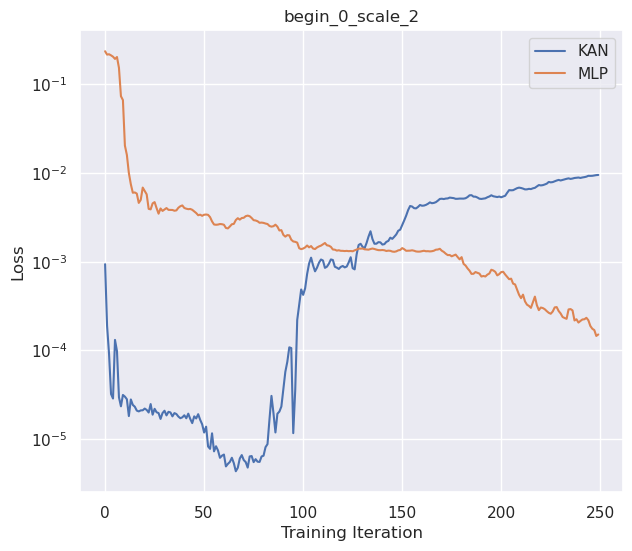

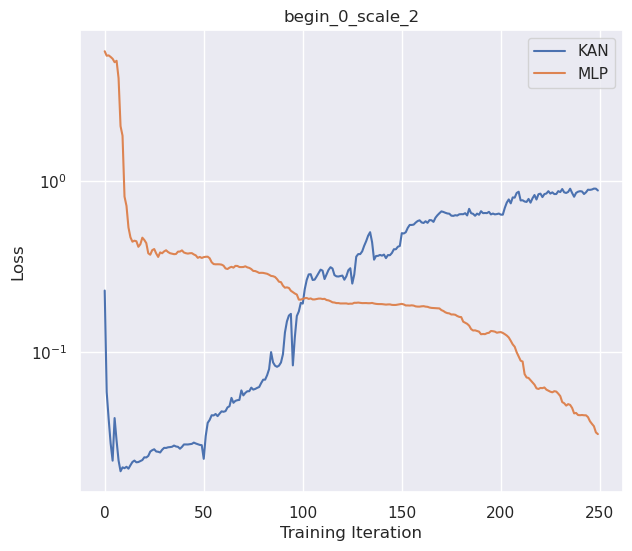

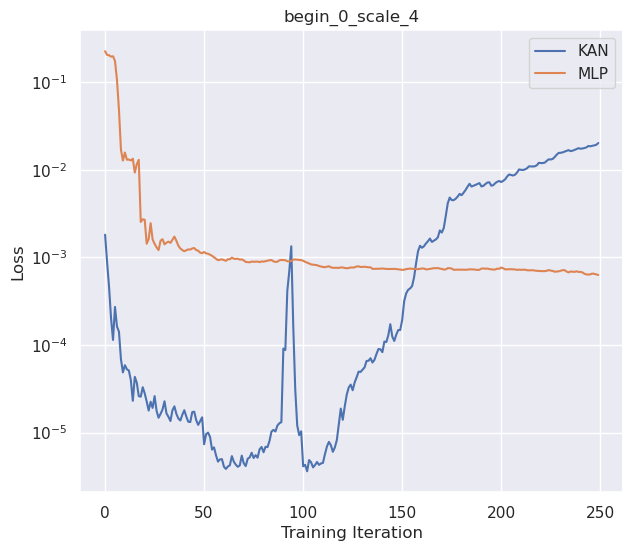

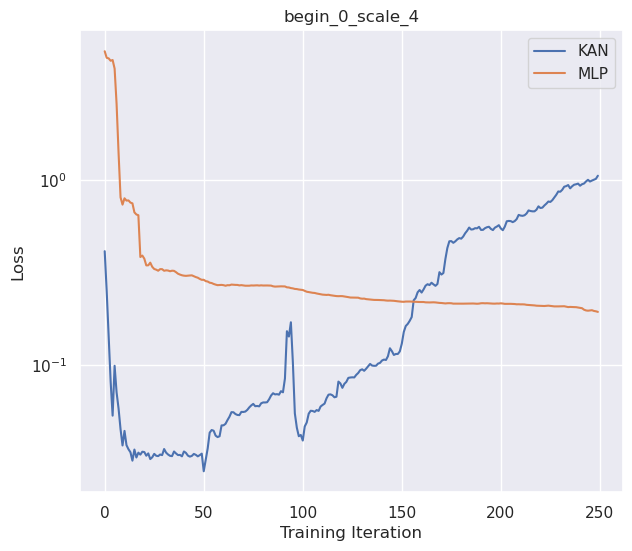

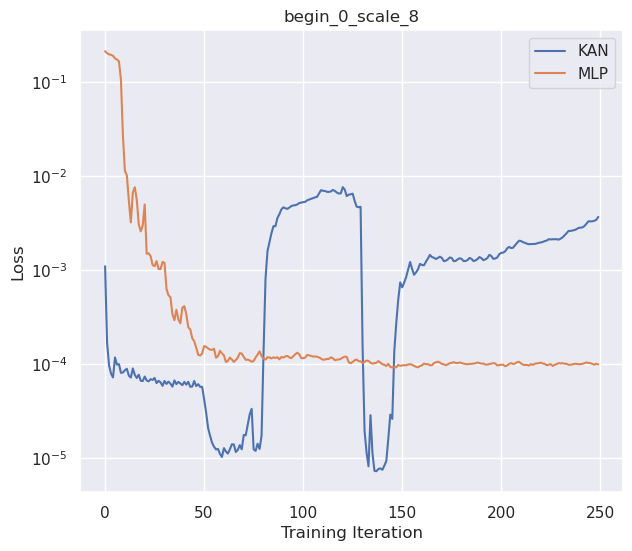

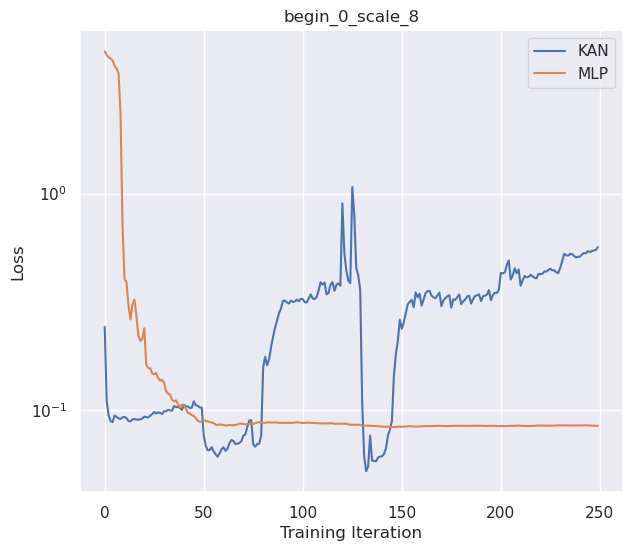

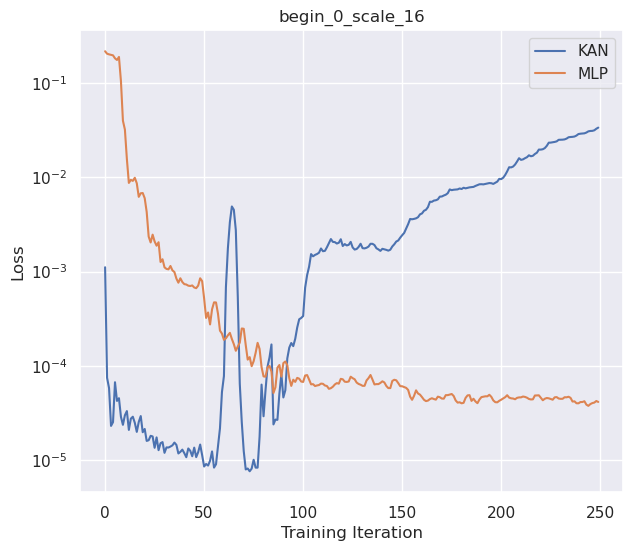

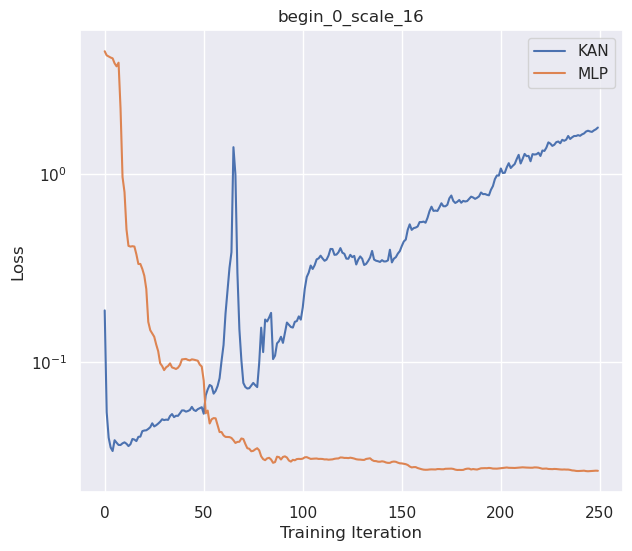

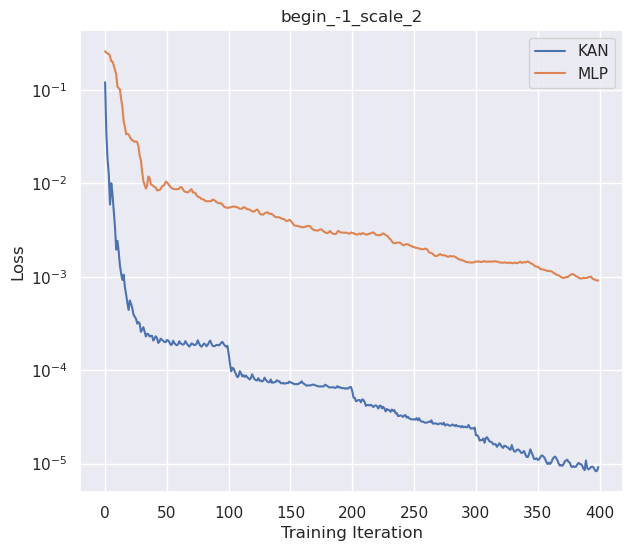

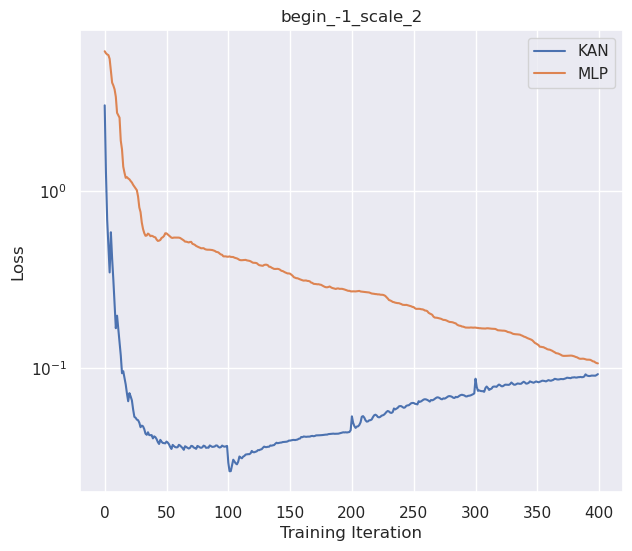

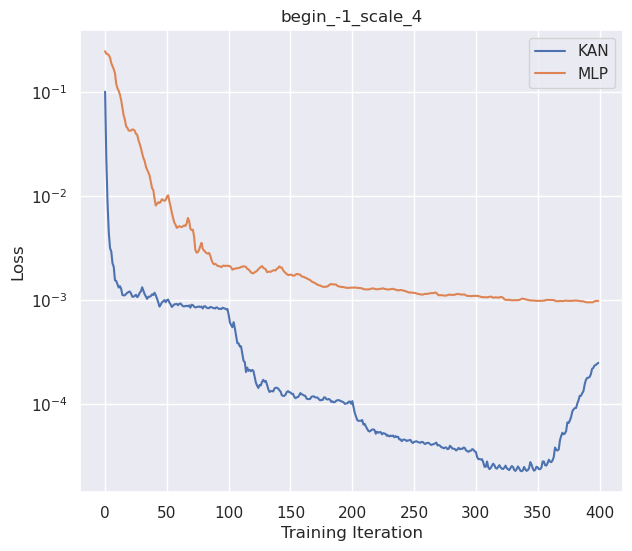

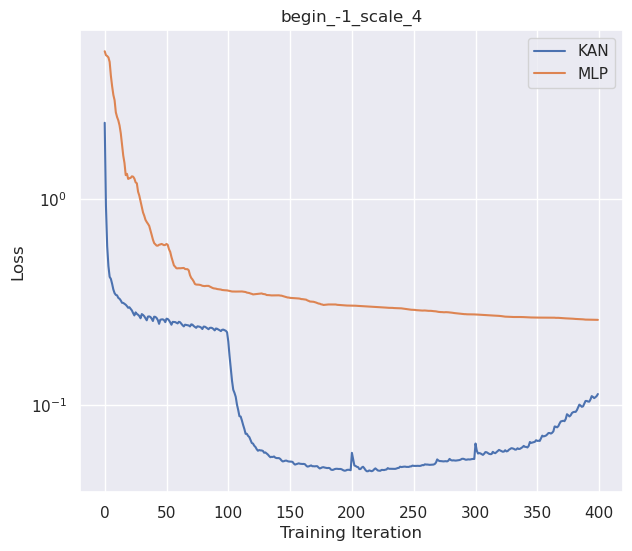

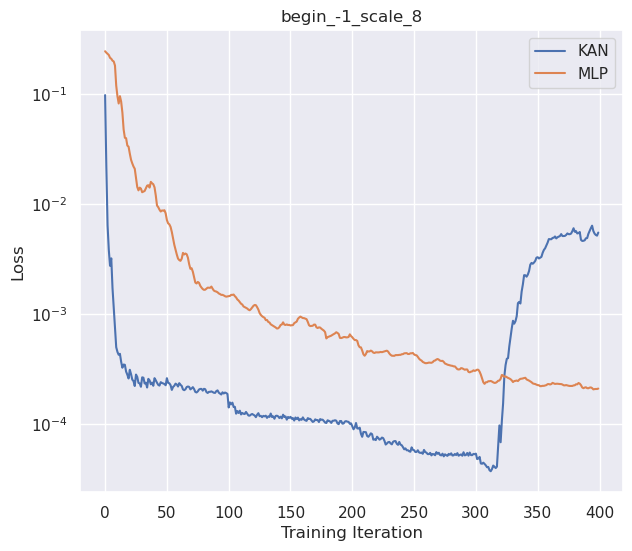

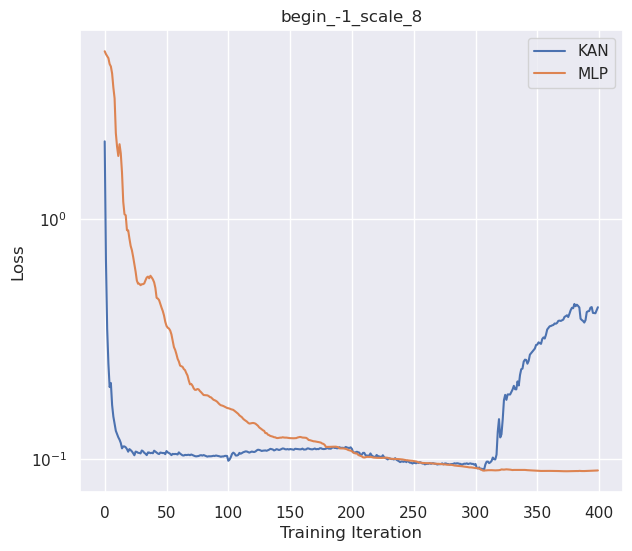

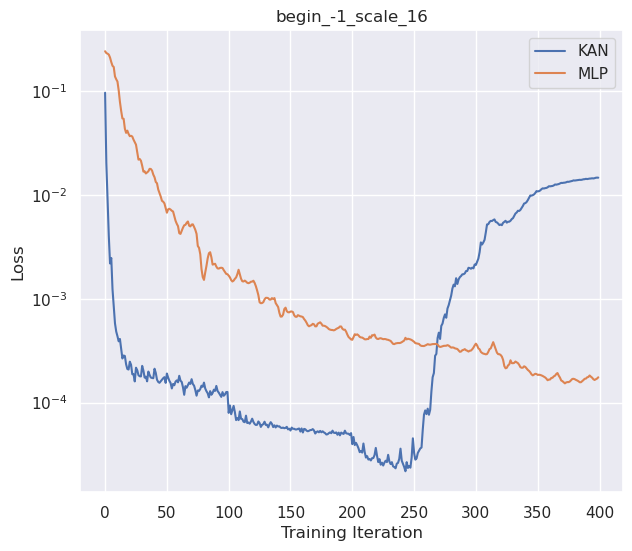

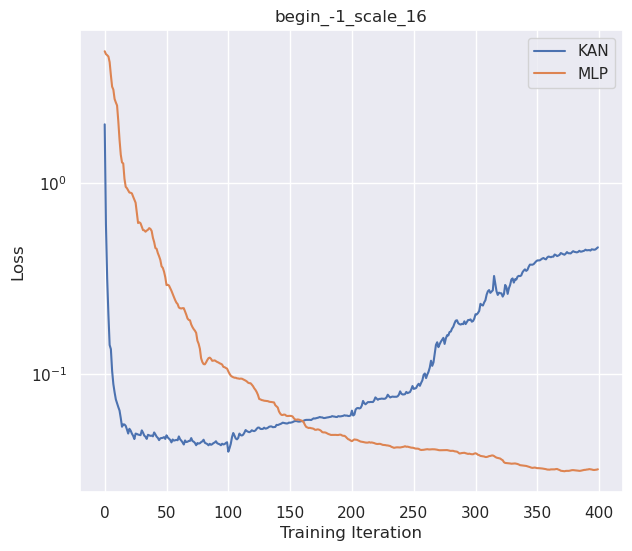

In [14]:
import numpy as np
from matplotlib import pyplot as plt
scales = [2,4,8,16]
begins = [0,-1]
losses = ['l2','h1']
model_choice = ['KAN','MLP']
for BEGIN in begins:
    for SCALE in scales:
        for loss in losses:
            plt.figure(figsize=(7, 6))
            for model in model_choice:
                array = np.loadtxt(f'{loss}drm2d_begin_{BEGIN}_frequency_{SCALE}_model_{model}.txt') 
                plt.plot(array,label=model)
            
            plt.yscale('log')
            plt.xlabel('Training Iteration')
            plt.ylabel('Loss')
            plt.title(f"begin_{BEGIN}_scale_{SCALE}")
            plt.legend()
            plt.savefig(f'{loss}drm2d_scale_{SCALE}.png')
            plt.show()